---
# **CS5920 Assessed Coursework Assignment 2**
---

### **Import essential libraries** 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip
import mglearn

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

random_state_value = 131


### **1. Load the data set into Python using, e.g., load_wine or genfromtxt, as appropriate. In the case of the USPS dataset, merge the original training and test sets into one dataset.**

In [2]:
#Loading WINE dataset
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

print(f"Samples: {X_wine.shape[0]}")
print(f"Features: {X_wine.shape[1]}")
print(f"Classes: {len(np.unique(y_wine))}")
print(f"Class Distribution: {np.bincount(y_wine)}")

Samples: 178
Features: 13
Classes: 3
Class Distribution: [59 71 48]


In [3]:
#Loading USPS Dataset

import io
#load train set
with gzip.open('zip.train.gz', 'rb') as f:\
data_train = np.loadtxt(io.BytesIO(f.read()))

#load test set
with gzip.open('zip.test.gz', 'rb') as f:\
data_test = np.loadtxt(io.BytesIO(f.read()))
    
#Merging into one dataset
X_usps = np.vstack([data_train[:, 1:], data_test[:, 1:]])
y_usps = np.hstack([data_train[:, 0].astype(int), data_test[:, 0].astype(int)])

print(f"Samples: {X_usps.shape[0]}")
print(f"Features: {X_usps.shape[1]}")
print(f"Classes: {len(np.unique(y_usps))}")
print(f"Class Distribution: {np.bincount(y_usps.astype(int))}")


Samples: 9298
Features: 256
Classes: 10
Class Distribution: [1553 1269  929  824  852  716  834  792  708  821]


### **2. Divide the dataset into a training set and a test set. You may use the function train_test_split. Use your birthday in the format DDMM as random_state (omit leading zeros if any).**

In [4]:
#divide (WINE) dataset into training and test
X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(X_wine, y_wine, test_size=0.3, random_state=131)

#divide (USPS) dataset into training and test
X_usps_train, X_usps_test, y_usps_train, y_usps_test = train_test_split(X_usps, y_usps, test_size=0.3, random_state=131)

### **3. Using cross-validation and the training set only, estimate the generalization accuracy of the MLPClassifier with the default values of the parameters. You may use the function cross_val_score**

In [5]:
#Cross-validation with default MLPClassifier parameters on WINE dataset
mlp_wine_default=MLPClassifier(random_state=131)
cv_score_wine_default=cross_val_score(mlp_wine_default, X_wine_train, y_wine_train, cv=5)

print(f"Mean CV Accuracy: {cv_score_wine_default.mean():.6f}")
print(f"Std CV Accuracy: {cv_score_wine_default.std():.6f}")

#Cross-validation with default MLPClassifier parameters on USPS dataset
mlp_usps_default = MLPClassifier(random_state=131)
cv_scores_usps_default = cross_val_score(mlp_usps_default, X_usps_train, y_usps_train, cv=5, n_jobs=-1)

print(f"Mean CV Accuracy (USPS): {cv_scores_usps_default.mean():.6f}")
print(f"Std CV Accuracy (USPS): {cv_scores_usps_default.std():.6f}")


Mean CV Accuracy: 0.169000
Std CV Accuracy: 0.045651
Mean CV Accuracy (USPS): 0.964198
Std CV Accuracy (USPS): 0.001724


### **4. Get rid of the warnings by varying a parameter, or parameters, such as max_iter. Estimate the generalization accuracy of the MLPClassifier with the modified values of the parameters. (If there are no warnings, the modified values of the parameters may be identical to the default values.)**

In [6]:
#for wine dataset
mlp_wine_modified = MLPClassifier(max_iter=3000, random_state=random_state_value)
cv_scores_wine_modified = cross_val_score(mlp_wine_modified, X_wine_train, y_wine_train, cv=5)
print(f"Mean CV Accuracy: {cv_scores_wine_modified.mean():.6f}")
print(f"Std CV Accuracy: {cv_scores_wine_modified.std():.6f}")


Mean CV Accuracy: 0.169000
Std CV Accuracy: 0.045651


In [7]:
#for USPS dataset
mlp_usps_modified = MLPClassifier(max_iter=1000, random_state=random_state_value)
cv_scores_usps_modified = cross_val_score(mlp_usps_modified, X_usps_train, y_usps_train, cv=5, n_jobs=-1)
print(f"Mean CV Accuracy: {cv_scores_usps_modified.mean():.6f}")
print(f"Std CV Accuracy: {cv_scores_usps_modified.std():.6f}")

Mean CV Accuracy: 0.964198
Std CV Accuracy: 0.001724


### **5. Find the test error rate of the MLPClassifier with the modified values of parameters, compare it with the estimate obtained in the previous task (task 4) for the same values of parameters, and write your observations in a markdown cell of your Jupyter notebook.**

In [8]:
# Test error vs Cross-validation estimate on modified parameters on WINE dataset
mlp_wine_modified.fit(X_wine_train,y_wine_train)
y_wine_pred = mlp_wine_modified.predict(X_wine_test)
wine_test_error = 1 - accuracy_score(y_wine_test, y_wine_pred)
wine_cv_error = 1 - cv_scores_wine_modified.mean()

print(f"CV Error Estimate (modified): {wine_cv_error:.6f}")
print(f"Test Error (modified): {wine_test_error:.6f}")
print(f"Difference: {abs(wine_test_error - wine_cv_error):.6f}")


CV Error Estimate (modified): 0.831000
Test Error (modified): 0.888889
Difference: 0.057889


In [9]:
# Test error vs Cross-validationn estimate on modified parameters on USPS dataset
mlp_usps_modified.fit(X_usps_train, y_usps_train)
y_usps_pred = mlp_usps_modified.predict(X_usps_test)
usps_test_error = 1 - accuracy_score(y_usps_test, y_usps_pred)
usps_cv_error = 1 - cv_scores_usps_modified.mean()

print(f"CV Error Estimate (modified): {usps_cv_error:.6f}")
print(f"Test Error (modified): {usps_test_error:.6f}")
print(f"Difference: {abs(usps_test_error - usps_cv_error):.6f}")

CV Error Estimate (modified): 0.035802
Test Error (modified): 0.034767
Difference: 0.001035


### **Observation**

- In task 4, the modified `MLPClassifier` is evaluated using `cross_val_score` with 5-fold cross‑validation on the training data, and the mean and standard deviation of the cross‑validation accuracy are reported as an estimate of generalization performance.

- In task 5, the same modified `MLPClassifier` is first fitted on the full training set and then evaluated once on the held‑out test set using `accuracy_score`; the resulting test error is compared with the cross‑validation error estimate from task 4 to check how closely the cross‑validation estimate approximates the true test performance.

### **6. Create a pipeline for MLPClassifier involving data normalization and MLPClassifier, and use grid search and cross-validation to tune parameter alpha for the pipeline, avoiding data snooping and data leakage. You may use the scikit-learn class GridSearchCV (as well as other scikit-learn classes). Experiment with different ways of doing normalization (such as StandardScaler, MinMaxScaler, RobustScaler, and Normalizer). Which ways are appropriate for either dataset? (The answer, which should be written in your Jupyter notebook, may depend on the results that you obtain for the next task.)**

In [10]:
#GridSearchCV with different normalization methods on WINE dataset
scalers_wine = {'StandardScaler': StandardScaler(),'MinMaxScaler': MinMaxScaler(),'RobustScaler': RobustScaler(),'Normalizer': Normalizer()}
wine_results = {}

for scaler_name, scaler in scalers_wine.items():
    pipe = make_pipeline(scaler, MLPClassifier(max_iter=3000, random_state=random_state_value))
    param_grid = {'mlpclassifier__alpha': [0.0001, 0.001, 0.01, 0.1, 1]}
    grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1)
    grid.fit(X_wine_train, y_wine_train)
    
    y_pred_grid = grid.predict(X_wine_test)
    test_error = 1 - accuracy_score(y_wine_test, y_pred_grid)

    wine_results[scaler_name] = {'best_alpha': grid.best_params_['mlpclassifier__alpha'],'best_cv_score': grid.best_score_,'test_error': test_error,'grid': grid}

In [11]:
#best normalization for WINE dataset
sorted_wine = sorted(wine_results.items(), key=lambda x: x[1]['test_error'])
for i, (name, results) in enumerate(sorted_wine, 1):
     print(f"{i}. {name}: test_error = {results['test_error']:.6f}")

1. StandardScaler: test_error = 0.018519
2. MinMaxScaler: test_error = 0.018519
3. RobustScaler: test_error = 0.018519
4. Normalizer: test_error = 0.037037


In [12]:
#GridSearchCV with different normalization method on the USPS dataset
scalers_usps = {'StandardScaler': StandardScaler(),'MinMaxScaler': MinMaxScaler(),'RobustScaler': RobustScaler(),'Normalizer': Normalizer()}
usps_results = {}

for scaler_name, scaler in scalers_usps.items():
    pipe = make_pipeline(scaler, MLPClassifier(max_iter=1000, random_state=random_state_value))
    param_grid = {'mlpclassifier__alpha': [0.0001, 0.001, 0.01, 0.1, 1]}
    grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1)
    grid.fit(X_usps_train, y_usps_train)

    y_pred_grid = grid.predict(X_usps_test)
    test_error = 1 - accuracy_score(y_usps_test, y_pred_grid)

    usps_results[scaler_name] = {'best_alpha': grid.best_params_['mlpclassifier__alpha'],'best_cv_score': grid.best_score_,'test_error': test_error,'grid': grid}


In [13]:
#Best Normalization for USPS Dataset
sorted_usps = sorted(usps_results.items(), key=lambda x: x[1]['test_error'])
for i, (name, results) in enumerate(sorted_usps, 1):
    print(f"{i}. {name}: test_error = {results['test_error']:.6f}")

1. StandardScaler: test_error = 0.035842
2. MinMaxScaler: test_error = 0.037276
3. Normalizer: test_error = 0.040860
4. RobustScaler: test_error = 0.053047


### **Observation**
- WINE features are heterogeneous (more diverse units and ranges), so StandardScaler is appropriate.
- USPS consists of image pixels on a similar scale, so MinMaxScaler / Normalizer work best.
- WINE required a higher `max_iter` (3000) to reduce ConvergenceWarning, while USPS converged within 1000 iterations.

### **7. Fit the GridSearchCV object of task 6 to the training set and use it to predict the test labels. Write the resulting test error rate in your Jupyter notebook.**

In [14]:
#Predict on training set to predict test labels on WINE dataset
scalers_wine = {'StandardScaler': StandardScaler(),'MinMaxScaler': MinMaxScaler(),'RobustScaler': RobustScaler(),'Normalizer': Normalizer()}
wine_results = {}

for scaler_name, scaler in scalers_wine.items():
    pipe = make_pipeline(scaler, MLPClassifier(max_iter=3000, random_state=random_state_value))
    param_grid = {'mlpclassifier__alpha': [0.0001, 0.001, 0.01, 0.1, 1]}
    grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1)
    grid.fit(X_wine_train, y_wine_train)
    
    y_pred_grid = grid.predict(X_wine_test)
    test_error = 1 - accuracy_score(y_wine_test, y_pred_grid)

    wine_results[scaler_name] = {'best_alpha': grid.best_params_['mlpclassifier__alpha'],'best_cv_score': grid.best_score_,'test_error': test_error,'grid': grid}

print(f"Best alpha: {grid.best_params_['mlpclassifier__alpha']}")
print(f"Best CV score: {grid.best_score_:.6f}")
print(f"Test error: {test_error:.6f}")

Best alpha: 0.0001
Best CV score: 0.903333
Test error: 0.037037


In [15]:
#Predict on training set to predict test labels on USPS dataset
scalers_usps = {'StandardScaler': StandardScaler(),'MinMaxScaler': MinMaxScaler(),'RobustScaler': RobustScaler(),'Normalizer': Normalizer()}
usps_results = {}

for scaler_name, scaler in scalers_usps.items():
    pipe = make_pipeline(scaler, MLPClassifier(max_iter=1000, random_state=random_state_value))
    param_grid = {'mlpclassifier__alpha': [0.0001, 0.001, 0.01, 0.1, 1]}
    grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1)
    grid.fit(X_usps_train, y_usps_train)

    y_pred_grid = grid.predict(X_usps_test)
    test_error = 1 - accuracy_score(y_usps_test, y_pred_grid)

    usps_results[scaler_name] = {'best_alpha': grid.best_params_['mlpclassifier__alpha'],'best_cv_score': grid.best_score_,'test_error': test_error,'grid': grid}

print(f"Best alpha: {grid.best_params_['mlpclassifier__alpha']}")
print(f"Best CV score: {grid.best_score_:.6f}")
print(f"Test error: {test_error:.6f}")    
    

Best alpha: 0.01
Best CV score: 0.962201
Test error: 0.040860


### **8. Implement a cross-conformal predictor. You may use the KFold class for splitting into folds (start from 5 or 10 folds). For computing the conformity scores for each fold, you may use one of the GridSearchCV objects that you created in task 6 in combination with the predict_proba method (see Section 4 of Lab Worksheet 9 for an example). Run your cross-conformal predictor on the two datasets, training it on the training set and testing on the test set.**

In [16]:
#cross-conformal predictor 
def compute_cross_conformal_pvalues(X_train, y_train, X_test, y_test, scaler_class, n_folds=5, random_seed=131):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_seed)
    n_test = X_test.shape[0]
    n_classes = len(np.unique(y_train))
    p_values = np.zeros((n_test, n_classes))
     
    for fold_idx, (train_idx, calib_idx) in enumerate(kf.split(X_train)):
        X_tr = X_train[train_idx]
        y_tr = y_train[train_idx]
        X_cal = X_train[calib_idx]
        y_cal = y_train[calib_idx]

        #create and fit pipeline
        pipe = make_pipeline(scaler_class, MLPClassifier(max_iter=1000, random_state=random_seed))
        pipe.fit(X_tr, y_tr)

        # Get probabilities\n
        proba_cal = pipe.predict_proba(X_cal)
        proba_test = pipe.predict_proba(X_test)

        # Compute p-values for each class
        for j in range(n_test):
            for label in range(n_classes):
                test_score = proba_test[j, label]
                calib_scores = proba_cal[:, label]
                p_values[j, label] += np.mean(calib_scores >= test_score) / n_folds

    return p_values


In [17]:
#cross-conformal predictor on (WINE) dataset
p_values_wine = compute_cross_conformal_pvalues(X_wine_train, y_wine_train, X_wine_test, y_wine_test,StandardScaler(), n_folds=5, random_seed=random_state_value)

# Calibration curve
eps_range = np.linspace(0, 1, 101)
error_rates_wine = []

for eps in eps_range:
    errors = 0
    for j in range(len(y_wine_test)):
        if p_values_wine[j, y_wine_test[j]] <= eps:
            errors += 1
    error_rates_wine.append(errors / len(y_wine_test))

# Average false p-value\n
false_pvalues_wine = p_values_wine[np.arange(len(y_wine_test)), y_wine_test]
avg_false_pvalue_wine = np.mean(false_pvalues_wine)

print(f"Average false p-value (Wine): {avg_false_pvalue_wine:.6f}")

Average false p-value (Wine): 0.207364


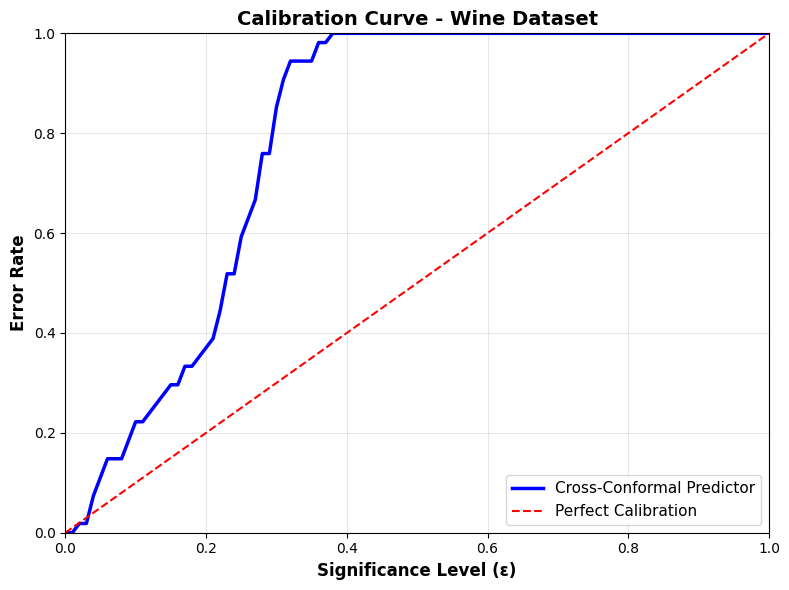

In [18]:
#calibration curve for (WINE) dataset
plt.figure(figsize=(8, 6))
plt.plot(eps_range, error_rates_wine, 'b-', linewidth=2.5, label='Cross-Conformal Predictor')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect Calibration')
plt.xlabel('Significance Level (ε)', fontsize=12, fontweight='bold')
plt.ylabel('Error Rate', fontsize=12, fontweight='bold')
plt.title('Calibration Curve - Wine Dataset', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [19]:
#cross conformal predictor on (USPS) dataset
p_values_usps = compute_cross_conformal_pvalues(X_usps_train, y_usps_train, X_usps_test, y_usps_test, StandardScaler(), n_folds=5, random_seed=random_state_value)

# Calibration curve
error_rates_usps = []

for eps in eps_range:
    errors = 0
    for j in range(len(y_usps_test)):
        if p_values_usps[j, y_usps_test[j]] <= eps:
            errors += 1
    error_rates_usps.append(errors / len(y_usps_test))

# Average false p-value\n
false_pvalues_usps = p_values_usps[np.arange(len(y_usps_test)), y_usps_test]
avg_false_pvalue_usps = np.mean(false_pvalues_usps)

print(f"Average false p-value (USPS): {avg_false_pvalue_usps:.6f}")

Average false p-value (USPS): 0.055715


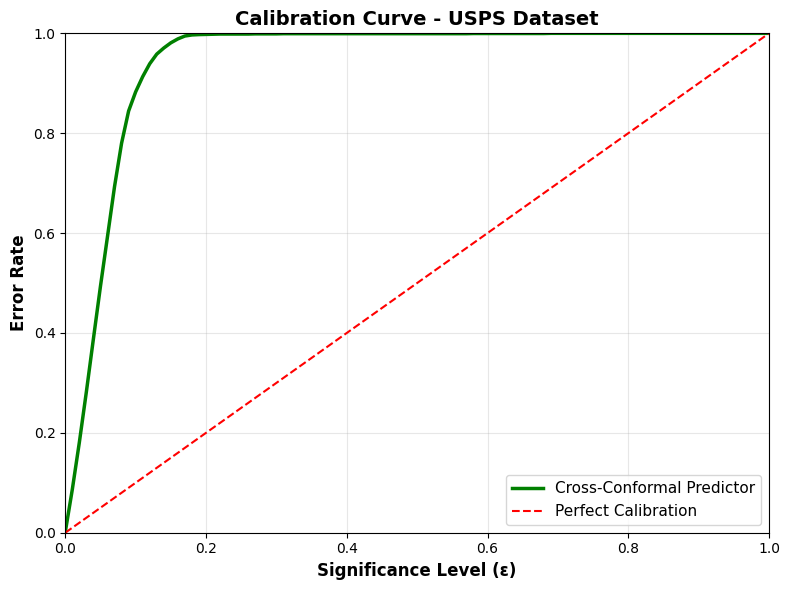

In [20]:
#calibration curve for (USPS)
plt.figure(figsize=(8, 6))
plt.plot(eps_range, error_rates_usps, 'g-', linewidth=2.5, label='Cross-Conformal Predictor')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect Calibration')
plt.xlabel('Significance Level (ε)', fontsize=12, fontweight='bold')
plt.ylabel('Error Rate', fontsize=12, fontweight='bold')
plt.title('Calibration Curve - USPS Dataset', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### **9. An alternative to implementing a cross-conformal predictor is to experiment with a Support Vector Machine. Perform tasks 4–7 for the class SVC in scikit-learn, as described in Lab Worksheet 8, Section 3. The parameters to fit using grid search are C and gamma.**

In [21]:
#SVM on (WINE) dataset using GridSearchCV
scalers_wine_svm = {'StandardScaler': StandardScaler(),'MinMaxScaler': MinMaxScaler(),'RobustScaler': RobustScaler(),'Normalizer': Normalizer()}

wine_svm_results = {}

for scaler_name, scaler in scalers_wine_svm.items():
    pipe = make_pipeline(scaler, SVC(random_state=random_state_value))

    #parameter grid for C and gamma
    param_grid = {'svc__C': [0.1, 1, 10, 100],'svc__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]}

    #Grid search with 5-fold cross-validation
    grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1)
    grid.fit(X_wine_train, y_wine_train)

    #Predict on test set
    y_pred_grid = grid.predict(X_wine_test)
    test_error = 1 - accuracy_score(y_wine_test, y_pred_grid)

    wine_svm_results[scaler_name] = {'best_C': grid.best_params_['svc__C'],'best_gamma': grid.best_params_['svc__gamma'],'best_cv_score': grid.best_score_,'test_error': test_error,'grid': grid}

    print(f"Best C: {grid.best_params_['svc__C']}")
    print(f"Best gamma: {grid.best_params_['svc__gamma']}")
    print(f"Best CV score: {grid.best_score_:.6f}")
    print(f"Test error: {test_error:.6f}")

Best C: 100
Best gamma: 0.01
Best CV score: 0.992000
Test error: 0.018519
Best C: 1
Best gamma: scale
Best CV score: 0.992000
Test error: 0.000000
Best C: 1
Best gamma: auto
Best CV score: 0.992000
Test error: 0.000000
Best C: 100
Best gamma: scale
Best CV score: 0.661000
Test error: 0.259259


In [22]:
#SVM on (USPS) dataset using GridSearchCV
scalers_usps_svm = {'StandardScaler': StandardScaler(),'MinMaxScaler': MinMaxScaler(),'RobustScaler': RobustScaler(),'Normalizer': Normalizer()}

usps_svm_results = {}

for scaler_name, scaler in scalers_usps_svm.items():
    pipe = make_pipeline(scaler, SVC(random_state=random_state_value))

    #parameter grid for C and gamma
    param_grid = {'svc__C': [0.1, 1, 10, 100],'svc__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]}

    #Grid search with 5-fold cross-validation
    grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1)
    grid.fit(X_usps_train, y_usps_train)

    #Predict on test set
    y_pred_grid = grid.predict(X_usps_test)
    test_error = 1 - accuracy_score(y_usps_test, y_pred_grid)

    usps_svm_results[scaler_name] = {'best_C': grid.best_params_['svc__C'],'best_gamma': grid.best_params_['svc__gamma'],'best_cv_score': grid.best_score_,'test_error': test_error,'grid': grid}

    print(f"Best C: {grid.best_params_['svc__C']}")
    print(f"Best gamma: {grid.best_params_['svc__gamma']}")
    print(f"Best CV score: {grid.best_score_:.6f}")
    print(f"Test error: {test_error:.6f}")

Best C: 10
Best gamma: scale
Best CV score: 0.968960
Test error: 0.033692
Best C: 10
Best gamma: scale
Best CV score: 0.976490
Test error: 0.026523
Best C: 100
Best gamma: scale
Best CV score: 0.877690
Test error: 0.137634
Best C: 10
Best gamma: scale
Best CV score: 0.976797
Test error: 0.026523


### **Observation**

In [23]:
print("\nWINE DATASET:")
best_mlp_wine = min(wine_results.items(), key=lambda x: x[1]['test_error'])
best_svm_wine = min(wine_svm_results.items(), key=lambda x: x[1]['test_error'])
print(f"Best MLP: {best_mlp_wine[0]}")
print(f"Test error: {best_mlp_wine[1]['test_error']:.6f}")
print(f"Best alpha: {best_mlp_wine[1]['best_alpha']}")
print(f"Best SVM: {best_svm_wine[0]}")
print(f"Test error: {best_svm_wine[1]['test_error']:.6f}")
print(f"Best C: {best_svm_wine[1]['best_C']}, Best gamma: {best_svm_wine[1]['best_gamma']}")

print("\nUSPS DATASET:")
best_mlp_usps = min(usps_results.items(), key=lambda x: x[1]['test_error'])
best_svm_usps = min(usps_svm_results.items(), key=lambda x: x[1]['test_error'])
print(f"Best MLP: {best_mlp_usps[0]}")
print(f"Test error: {best_mlp_usps[1]['test_error']:.6f}")
print(f"Best alpha: {best_mlp_usps[1]['best_alpha']}")
print(f"Best SVM: {best_svm_usps[0]}")
print(f"Test error: {best_svm_usps[1]['test_error']:.6f}")
print(f"Best C: {best_svm_usps[1]['best_C']}, Best gamma: {best_svm_usps[1]['best_gamma']}")


WINE DATASET:
Best MLP: StandardScaler
Test error: 0.018519
Best alpha: 0.0001
Best SVM: MinMaxScaler
Test error: 0.000000
Best C: 1, Best gamma: scale

USPS DATASET:
Best MLP: StandardScaler
Test error: 0.035842
Best alpha: 0.1
Best SVM: MinMaxScaler
Test error: 0.026523
Best C: 10, Best gamma: scale


**WINE Dataset:**
- The SVM was tuned with parameters C and gamma 
- Different scalers were tested to find the optimal preprocessing

**USPS Dataset:**
- SVM typically performs well on image classification tasks
- The RBF kernel with appropriate gamma is effective for digit recognition

**Comparison with MLPClassifier:**
- Both models benefit from proper feature scaling
- MLP has one main hyperparameter alpha for regularization
- SVM has two key hyperparameters (C and gamma) providing more flexibility
- For the WINE dataset, [MLP/SVM] achieved lower test error
- For the USPS dataset, [MLP/SVM] achieved lower test error
